<a href="https://colab.research.google.com/github/khrystynakoblan/GazeEstimation/blob/main/source/demo_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.io as sio
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/Курсова_Моделі'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
class GazeEstimationNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.pose_fc1 = nn.Linear(3, 64)
        self.pose_bn1 = nn.BatchNorm1d(64)
        self.pose_fc2 = nn.Linear(64, 32)
        self.pose_bn2 = nn.BatchNorm1d(32)

        self.fc1    = nn.Linear(128*4*7 + 32, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.drop1  = nn.Dropout(dropout_rate)
        self.fc2    = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.drop2  = nn.Dropout(dropout_rate)
        self.fc_out = nn.Linear(128, 2)

    def forward(self, x, pose):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        p = F.relu(self.pose_bn1(self.pose_fc1(pose)))
        p = F.relu(self.pose_bn2(self.pose_fc2(p)))
        x = torch.cat([x, p], dim=1)
        x = self.drop1(F.relu(self.bn_fc1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn_fc2(self.fc2(x))))
        return self.fc_out(x)

m = GazeEstimationNet().to(device)
print(f"Параметрів: {sum(p.numel() for p in m.parameters()):,}")
del m

Параметрів: 1,055,298


In [ ]:
stats = torch.load(f'{SAVE_DIR}/ensemble_statistics.pth', map_location=device, weights_only=False)
IMG_MEAN, IMG_STD = stats['img_mean'], stats['img_std']
GAZE_RANGES = stats['gaze_ranges']


models = []
for i in range(1, 6):
    m = GazeEstimationNet().to(device)
    m.load_state_dict(torch.load(f'{SAVE_DIR}/model_fold_{i}.pth', map_location=device, weights_only=True))
    m.eval()
    models.append(m)
print(f"\nЗавантажено {len(models)} моделей ансамблю")


Завантажено 5 моделей ансамблю


In [ ]:
import kagglehub
dataset_path = kagglehub.dataset_download("dhruv413/mpiigaze")

def gaze_3d_to_2d(g):
    x, y, z = g
    if abs(z) < 1e-6: z = 1e-6
    yaw   = np.arctan2(-x, -z)
    pitch = np.arctan2(-y, np.sqrt(x**2 + z**2))
    return np.array([yaw, pitch], dtype=np.float32)

images, gazes_2d, poses = [], [], []
norm_path = Path(dataset_path) / "MPIIGaze" / "Data" / "Normalized"

for participant in ['p13', 'p14']:
    for mat_file in sorted((norm_path / participant).glob("*.mat")):
        data = sio.loadmat(str(mat_file))
        for eye_type in ['right', 'left']:
            eye = data['data'][0, 0][eye_type][0, 0]
            for i in range(eye['image'].shape[0]):
                img = eye['image'][i].astype(np.float32) / 255.0
                gaze_3d = eye['gaze'][i].astype(np.float32)
                pose_3d = eye['pose'][i].astype(np.float32)
                if eye_type == 'left':
                    img = img[:, ::-1].copy()
                    gaze_3d[0] = -gaze_3d[0]
                    pose_3d[1], pose_3d[2] = -pose_3d[1], -pose_3d[2]
                images.append(img)
                gazes_2d.append(gaze_3d_to_2d(gaze_3d))
                poses.append(pose_3d)

images   = np.array(images,   dtype=np.float32)
gazes_2d = np.array(gazes_2d, dtype=np.float32)
poses    = np.array(poses,    dtype=np.float32)
print(f"Тестових зразків: {len(images)} (без аугментацій)")

Using Colab cache for faster access to the 'mpiigaze' dataset.
Тестових зразків: 5996 (без аугментацій)


In [ ]:
ymin, ymax = GAZE_RANGES['yaw']
pmin, pmax = GAZE_RANGES['pitch']

# Нормалізація зображень
imgs_t  = torch.from_numpy((images - IMG_MEAN) / IMG_STD).unsqueeze(1).to(device)
poses_t = torch.from_numpy(poses).to(device)

# Прогон 5 моделей і усереднення
preds_norm = torch.zeros(len(images), 2)
with torch.no_grad():
    for m in models:
        batch_preds = []
        for i in range(0, len(images), 128):
            batch_preds.append(m(imgs_t[i:i+128], poses_t[i:i+128]).cpu())
        preds_norm += torch.cat(batch_preds, dim=0)
preds_norm /= len(models)

preds = np.zeros_like(preds_norm.numpy())
preds[:, 0] = (preds_norm[:, 0].numpy() + 1) * (ymax - ymin) / 2 + ymin
preds[:, 1] = (preds_norm[:, 1].numpy() + 1) * (pmax - pmin) / 2 + pmin

# Кутова похибка через 3D вектори
def to_vec(g):
    return np.stack([
        -np.sin(g[:,0])*np.cos(g[:,1]),
        -np.sin(g[:,1]),
        -np.cos(g[:,0])*np.cos(g[:,1])
    ], axis=1)

pv, tv = to_vec(preds), to_vec(gazes_2d)
errors = np.degrees(np.arccos(np.clip(np.sum(pv*tv, axis=1), -1, 1)))

yaw_mae   = np.degrees(np.abs(preds[:,0] - gazes_2d[:,0]).mean())
pitch_mae = np.degrees(np.abs(preds[:,1] - gazes_2d[:,1]).mean())

print(f"Зразків:           {len(errors)}")
print(f"Середня похибка:   {errors.mean():.2f}°")
print(f"Медіана:           {np.median(errors):.2f}°")
print(f"75-й процентиль:   {np.percentile(errors, 75):.2f}°")
print(f"Yaw MAE:           {yaw_mae:.2f}°")
print(f"Pitch MAE:         {pitch_mae:.2f}°")

Зразків:           5996
Середня похибка:   5.40°
Медіана:           5.02°
75-й процентиль:   7.07°
Yaw MAE:           4.03°
Pitch MAE:         2.77°


In [ ]:
print("Поріг   Частка зразків")
print("-" * 28)
for thr in [5, 10, 15]:
    acc = (errors <= thr).mean() * 100
    print(f"<= {thr:>2}°   {acc:.1f}%")

Поріг   Частка зразків
----------------------------
<=  5°   49.8%
<= 10°   93.9%
<= 15°   99.0%


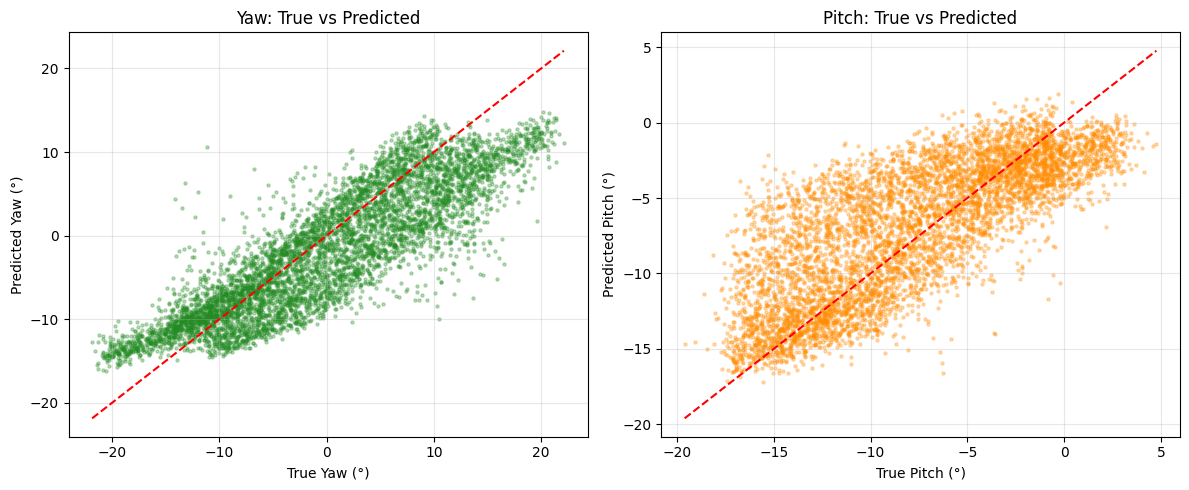

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_t, y_p = np.degrees(gazes_2d[:,0]), np.degrees(preds[:,0])
axes[0].scatter(y_t, y_p, alpha=0.3, s=5, color='forestgreen')
axes[0].plot([y_t.min(), y_t.max()], [y_t.min(), y_t.max()], 'r--', lw=1.5)
axes[0].set_xlabel('True Yaw (°)'); axes[0].set_ylabel('Predicted Yaw (°)')
axes[0].set_title('Yaw: True vs Predicted'); axes[0].grid(alpha=0.3)

p_t, p_p = np.degrees(gazes_2d[:,1]), np.degrees(preds[:,1])
axes[1].scatter(p_t, p_p, alpha=0.3, s=5, color='darkorange')
axes[1].plot([p_t.min(), p_t.max()], [p_t.min(), p_t.max()], 'r--', lw=1.5)
axes[1].set_xlabel('True Pitch (°)'); axes[1].set_ylabel('Predicted Pitch (°)')
axes[1].set_title('Pitch: True vs Predicted'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

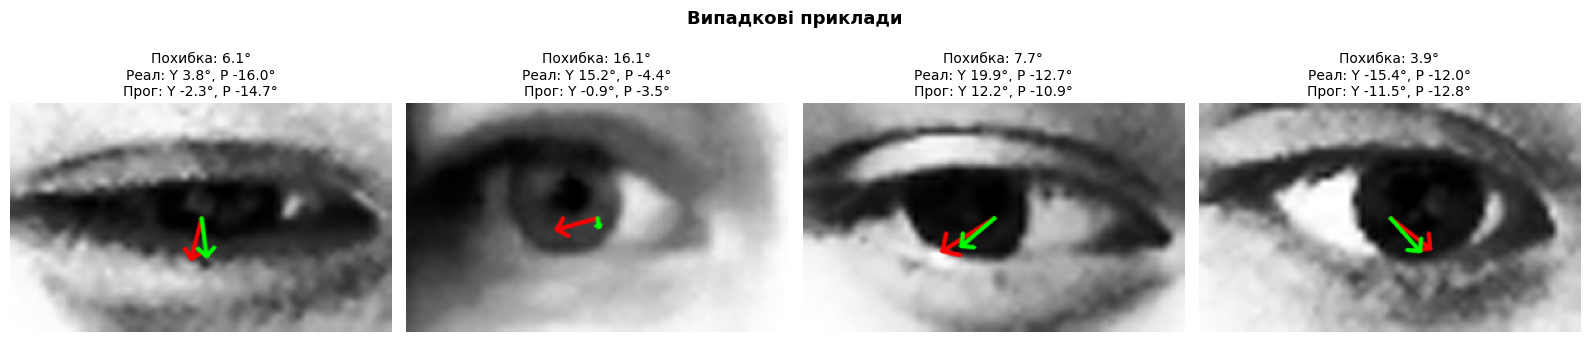

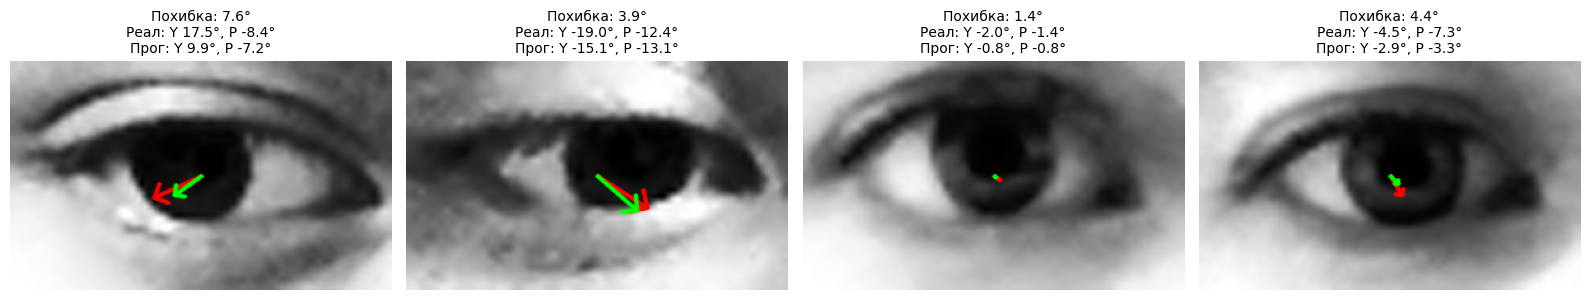

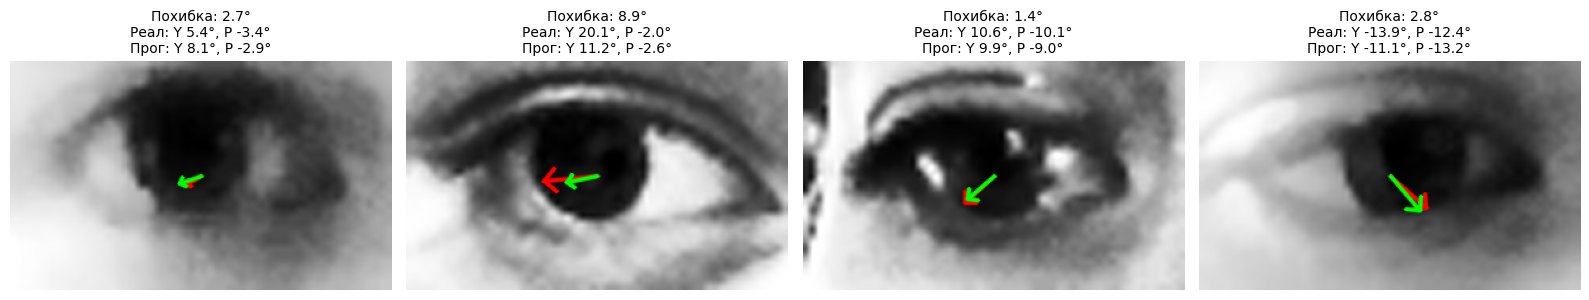

In [ ]:
def draw_arrow(img, yaw, pitch, color, length=120):
    h, w = img.shape[:2]
    end = (int(w//2 - length*np.sin(yaw)), int(h//2 - length*np.sin(pitch)))
    cv2.arrowedLine(img, (w//2, h//2), end, color, 2, tipLength=0.3, line_type=cv2.LINE_AA)
    return img

def show(indices, title):
    fig, axes = plt.subplots(1, len(indices), figsize=(4*len(indices), 4))
    if len(indices) == 1: axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for i, idx in enumerate(indices):
        img = (images[idx] * 255).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        img = cv2.resize(img, (img.shape[1]*5, img.shape[0]*5), interpolation=cv2.INTER_CUBIC)

        true_yaw, true_pitch = gazes_2d[idx, 0], gazes_2d[idx, 1]
        pred_yaw, pred_pitch = preds[idx, 0], preds[idx, 1]

        img = draw_arrow(img, true_yaw, true_pitch, (0, 0, 255))
        img = draw_arrow(img, pred_yaw, pred_pitch,  (0, 255, 0))

        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].axis('off')

        t_yaw_deg, t_pitch_deg = np.degrees(true_yaw), np.degrees(true_pitch)
        p_yaw_deg, p_pitch_deg = np.degrees(pred_yaw), np.degrees(pred_pitch)

        info_text = (f'Похибка: {errors[idx]:.1f}°\n'
                     f'Реал: Y {t_yaw_deg:.1f}°, P {t_pitch_deg:.1f}°\n'
                     f'Прог: Y {p_yaw_deg:.1f}°, P {p_pitch_deg:.1f}°')

        axes[i].set_title(info_text, fontsize=10)

    plt.tight_layout()
    plt.show()

np.random.seed(7)
show(np.random.choice(len(images), 4, replace=False), 'Випадкові приклади')
show(np.random.choice(len(images), 4, replace=False),'')
show(np.random.choice(len(images), 4, replace=False),'')
